In [63]:
# import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [ ]:
# Data import
import sys
sys.path.append("..")
from data_loader import get_data

X_tr, X_val, X_te, y_tr, y_val, y_te = get_data()

In [21]:
print(f"X_tr: {X_tr.shape}, X_val: {X_val.shape}, X_te: {X_te.shape}")
print(f"y_tr: {y_tr.shape}, y_val: {y_val.shape}, y_te: {y_te.shape}")

X_tr: (48000, 784), X_val: (12000, 784), X_te: (10000, 784)
y_tr: (48000,), y_val: (12000,), y_te: (10000,)


In [64]:
print(np.unique(y_tr))

[0 1 2 3 4 5 6 7 8 9]


In [80]:
# Data reshape and setup
X_tr_cnn = X_tr.reshape(-1,28,28,1)
X_val_cnn = X_val.reshape(-1,28,28,1)
X_te_cnn = X_te.reshape(-1,28,28,1)

print("Reshaped data:")
print(f"X_tr: {X_tr_cnn.shape}")
print(f"X_val: {X_val_cnn.shape}")
print(f"X_te: {X_te_cnn.shape}")

Reshaped data:
X_tr: (48000, 28, 28, 1)
X_val: (12000, 28, 28, 1)
X_te: (10000, 28, 28, 1)


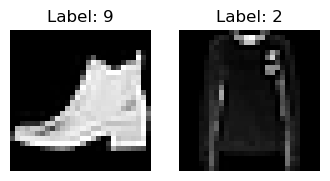

In [81]:
# Random shows data as image
fig, ax = plt.subplots(1,2,figsize=[4,4])
ax[0].imshow(X_tr_cnn[1325,:,:,0],cmap="gray")
ax[0].set_title(f'Label: {y_tr[1325]}')
ax[0].set_axis_off()

ax[1].imshow(X_tr_cnn[5678,:,:,0], cmap="gray")
ax[1].set_title(f'Label: {y_tr[5678]}')
ax[1].set_axis_off()

plt.show()

#### Train CNN

In [101]:
# Simplest model with 2 Convolution layers
model = models.Sequential([
    # First Convolution
    # 32 filters with 3x3, activation with relu
    layers.Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    # Pooling
    layers.MaxPool2D(pool_size=(2,2)),

    # Flatten
    layers.Flatten(),
    
    # Fully connected FNN
    layers.Dense(128, activation="relu"),
    # Output of P(y=k|x), k=0,1,...,9
    layers.Dense(10, activation="softmax")]
)

model.compile(optimizer="adam",
              loss="crossentropy",
              metrics=["accuracy"])

history = model.fit(X_tr_cnn, y_tr, epochs=10,batch_size=64, validation_data=[X_val_cnn, y_val])

/opt/anaconda3/envs/cs178/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8457 - loss: 0.4381 - val_accuracy: 0.8809 - val_loss: 0.3299
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8969 - loss: 0.2913 - val_accuracy: 0.8936 - val_loss: 0.3031
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9109 - loss: 0.2469 - val_accuracy: 0.9044 - val_loss: 0.2683
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9216 - loss: 0.2173 - val_accuracy: 0.9103 - val_loss: 0.2535
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9296 - loss: 0.1910 - val_accuracy: 0.9112 - val_loss: 0.2520
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9370 - loss: 0.1689 - val_accuracy: 0.9153 - val_loss: 0.2510
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9468 - loss: 0.1475 - val_accuracy: 0.9103 - val_loss: 0.2583
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9527 - loss: 0.1296 - val_accur

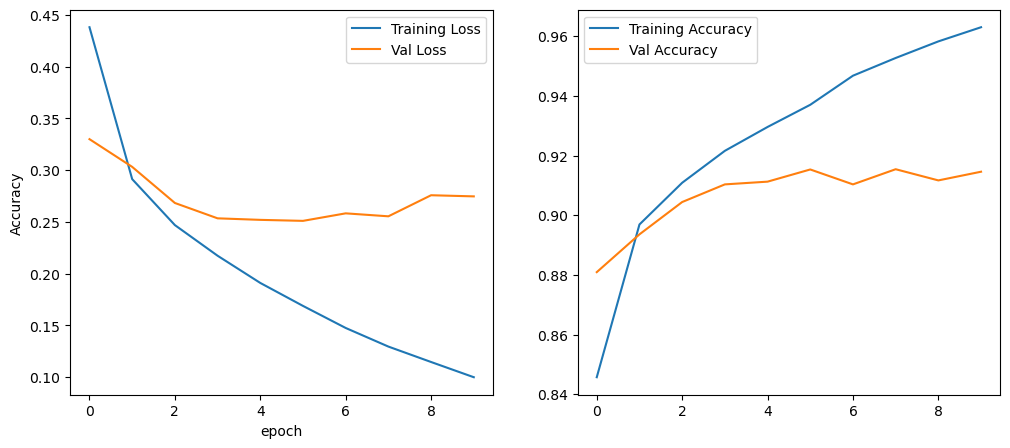

In [103]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(history.history["loss"], label="Training Loss")
ax[0].plot(history.history["val_loss"],label="Val Loss")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(history.history["accuracy"], label="Training Accuracy")
ax[1].plot(history.history["val_accuracy"], label="Val Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("Accuracy")
ax[1].legend()

plt.show()